In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns


In [2]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [3]:

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Cars24.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "balajimummidi/used-cars-in-cars24",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

C:\Users\HP\AppData\Local\Temp\ipykernel_4080\3887163167.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:    Unnamed: 0 Car Brand           Model   Price  Model Year   Location  \
0           0   Hyundai     EonERA PLUS  330399        2016  Hyderabad   
1           1    Maruti  Wagon R 1.0LXI  350199        2011  Hyderabad   
2           2    Maruti     Alto K10LXI  229199        2011  Hyderabad   
3           3    Maruti   RitzVXI BS IV  306399        2011  Hyderabad   
4           4      Tata   NanoTWIST XTA  208699        2015  Hyderabad   

     Fuel  Driven (Kms)       Gear  Ownership  EMI (monthly)  
0  Petrol         10674     Manual          2           7350  
1  Petrol         20979     Manual          1           7790  
2  Petrol         47330     Manual          2           5098  
3  Petrol         19662     Manual          1           6816  
4  Petrol         11256  Automatic          1           4642  


In [4]:
df.columns

Index(['Unnamed: 0', 'Car Brand', 'Model', 'Price', 'Model Year', 'Location',
       'Fuel', 'Driven (Kms)', 'Gear', 'Ownership', 'EMI (monthly)'],
      dtype='str')

<Axes: xlabel='Location', ylabel='num_of_cars'>

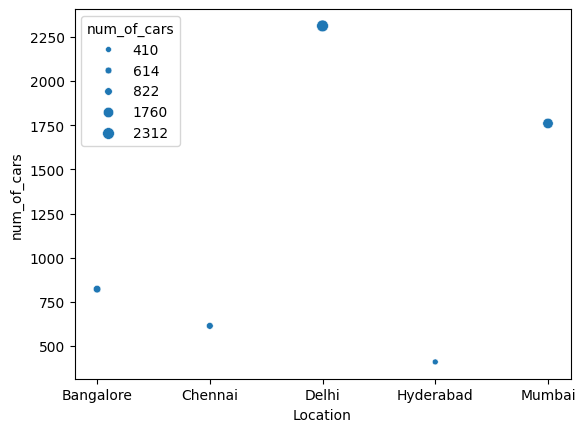

In [5]:
countries = df.groupby("Location").size().reset_index(name = "num_of_cars")
sns.scatterplot(
  data = countries,
    x= "Location",
    y= "num_of_cars",
    size = "num_of_cars"

)

#plt.show()
    

In [6]:
df["Location"].unique()

<StringArray>
['Hyderabad', 'Delhi', 'Mumbai', 'Bangalore', 'Chennai']
Length: 5, dtype: str

In [7]:
import plotly.express as px

C:\Users\HP\AppData\Local\Temp\ipykernel_4080\3866593329.py:16: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


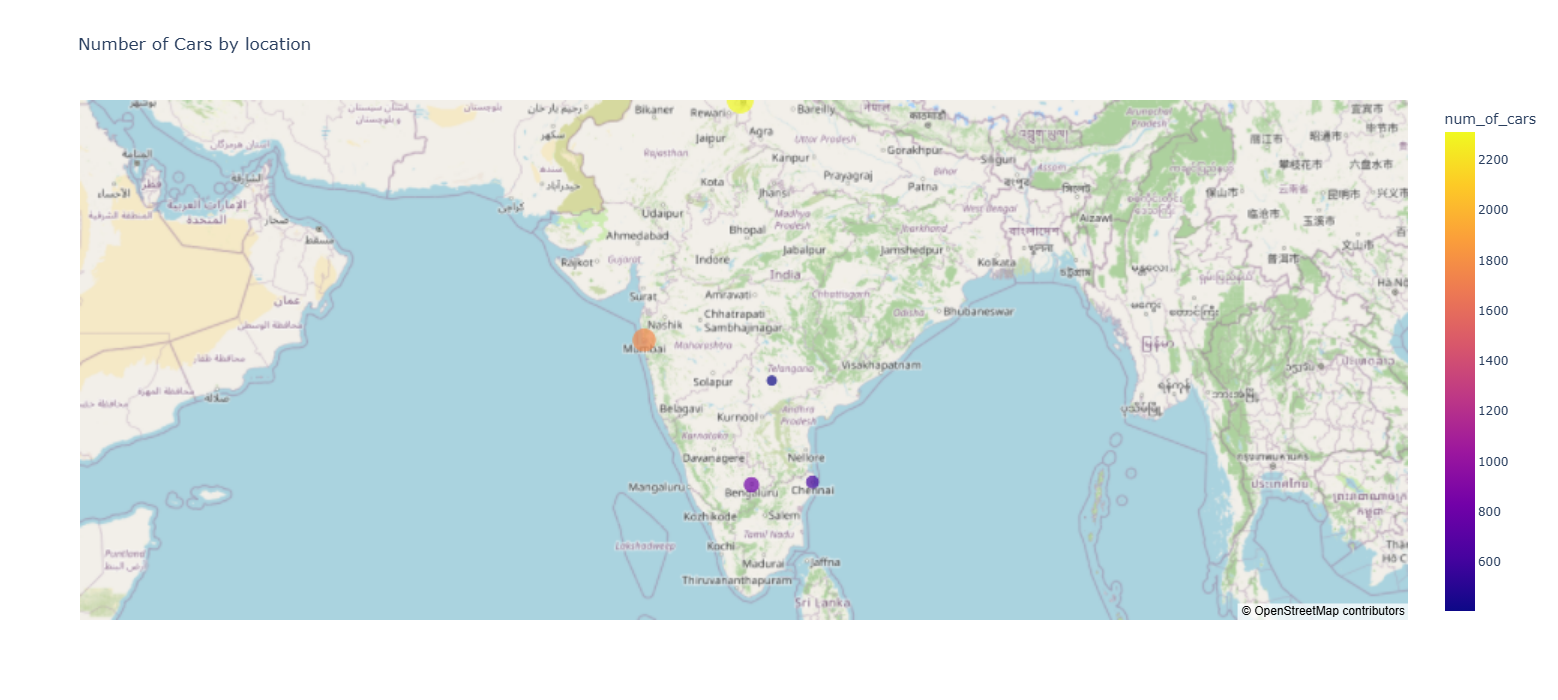

In [13]:
map_coordinates = {
"Hyderabad": [17.3850, 78.4867],
"Delhi": [28.7041, 77.1025],
"Mumbai": [19.0760, 72.8777],
"Bangalore": [12.9716, 77.5946],
"Chennai": [13.0827, 80.2707]
}

countries = df.groupby("Location").size().reset_index(name = "num_of_cars")

# adding laititude and attitude columns to the dataset
countries["Latitude"] = countries["Location"].map(lambda x: map_coordinates[x][0])
countries["Longitude"] = countries["Location"].map(lambda x: map_coordinates[x][1])

# plot thr map
fig = px.scatter_mapbox(
countries,
lat="Latitude",
lon="Longitude",
size="num_of_cars",
color="num_of_cars",
hover_name="Location",
hover_data=["num_of_cars"],
zoom=4,
height=700,
title="Number of Cars by location"
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()